# Notebook 10 - Framework Summary (Copenhagen)

Thin wrapper around `cityheat.nb10_summary.run_nb10_summary`.
It reads saved outputs from NB01-NB09 and writes summary figures to `outputs_variants/masselot_main/copenhagen/figures/summary/`.

In [1]:
import os
os.environ["URBAN_HEAT_OUTPUT_VARIANT"] = "masselot_main"
os.environ["IF_MAIN_FAMILY"] = "masselot_tail"


In [2]:
from pathlib import Path
import sys

def _find_root() -> Path:
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CITY_SLUG = "copenhagen"
ROOT

PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat')

In [3]:
from cityheat.nb10_summary_masselot_main import run_nb10_summary

results = run_nb10_summary(CITY_SLUG, verbose=True)
results

NB10 Masselot-main wrapper
  Output variant: masselot_main
  IF main family: masselot_tail
NB10 Summary Dashboard — Copenhagen (copenhagen)
Using outputs in /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen
[1_city_profile] saved -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_01_city_profile_copenhagen.png
[2_climate_hazard] saved -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_02_climate_hazard_copenhagen.png
[3_vulnerability] saved -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_03_vulnerability_copenhagen.png
[4_mortality_if] saved -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_04_m

{'1_city_profile': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_01_city_profile_copenhagen.png')],
 '2_climate_hazard': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_02_climate_hazard_copenhagen.png')],
 '3_vulnerability': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_03_vulnerability_copenhagen.png')],
 '4_mortality_if': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_04_mortality_if_copenhagen.png')],
 '5_policy_levers': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_05_policy_levers_copenhagen.png')],
 '

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_01_city_profile_copenhagen.png


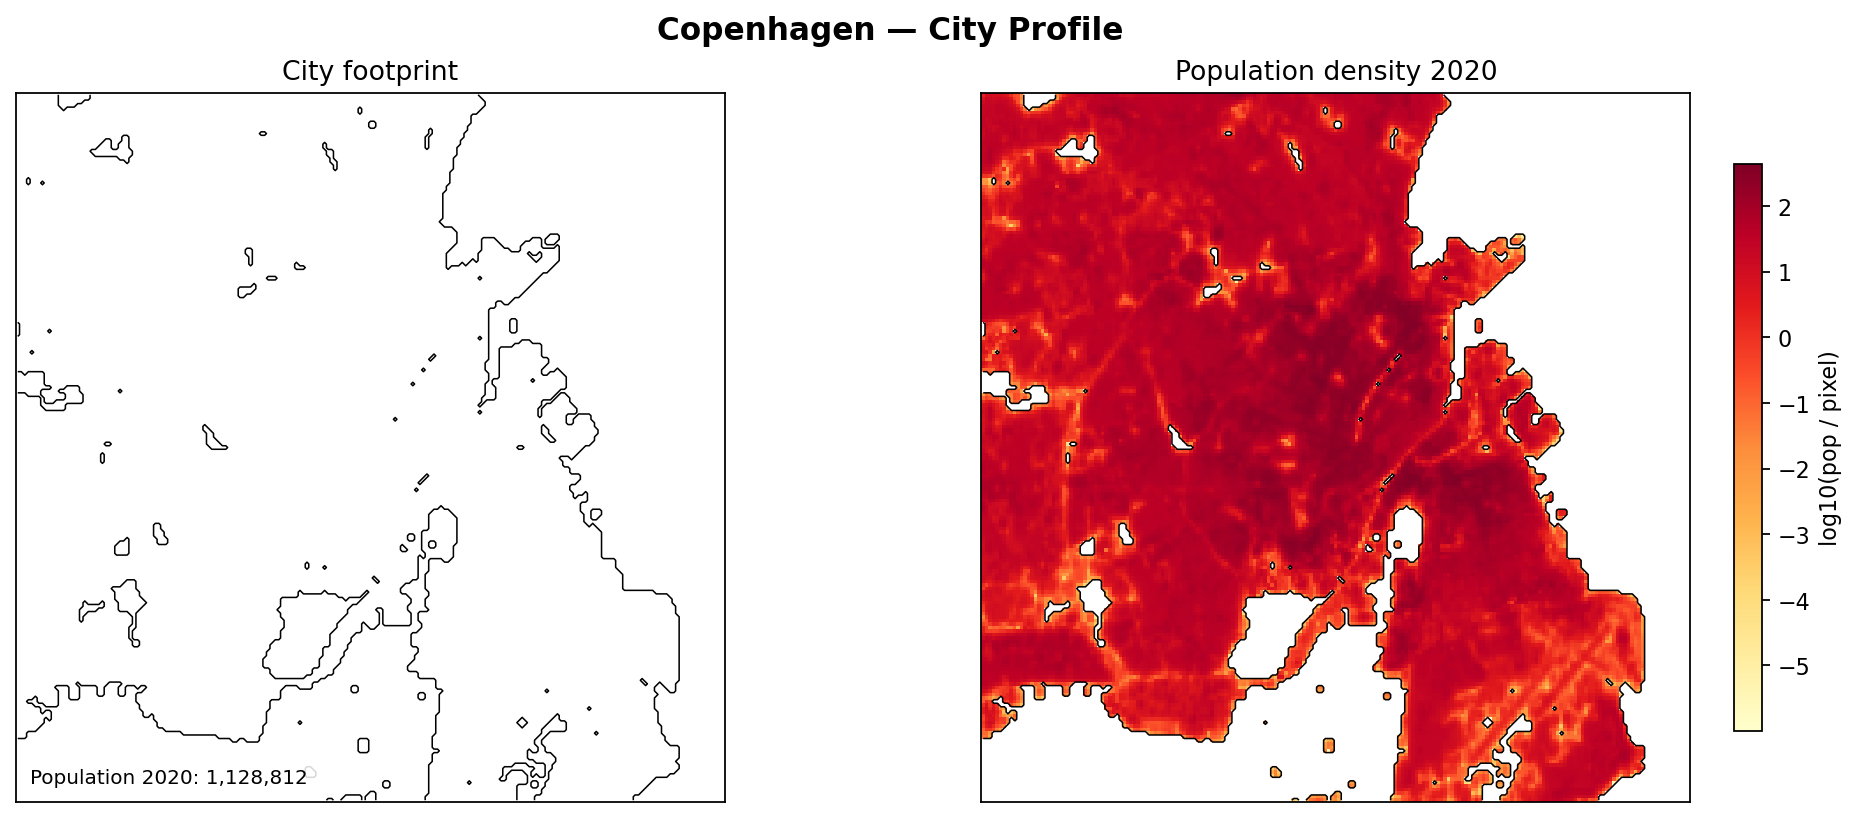

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_02_climate_hazard_copenhagen.png


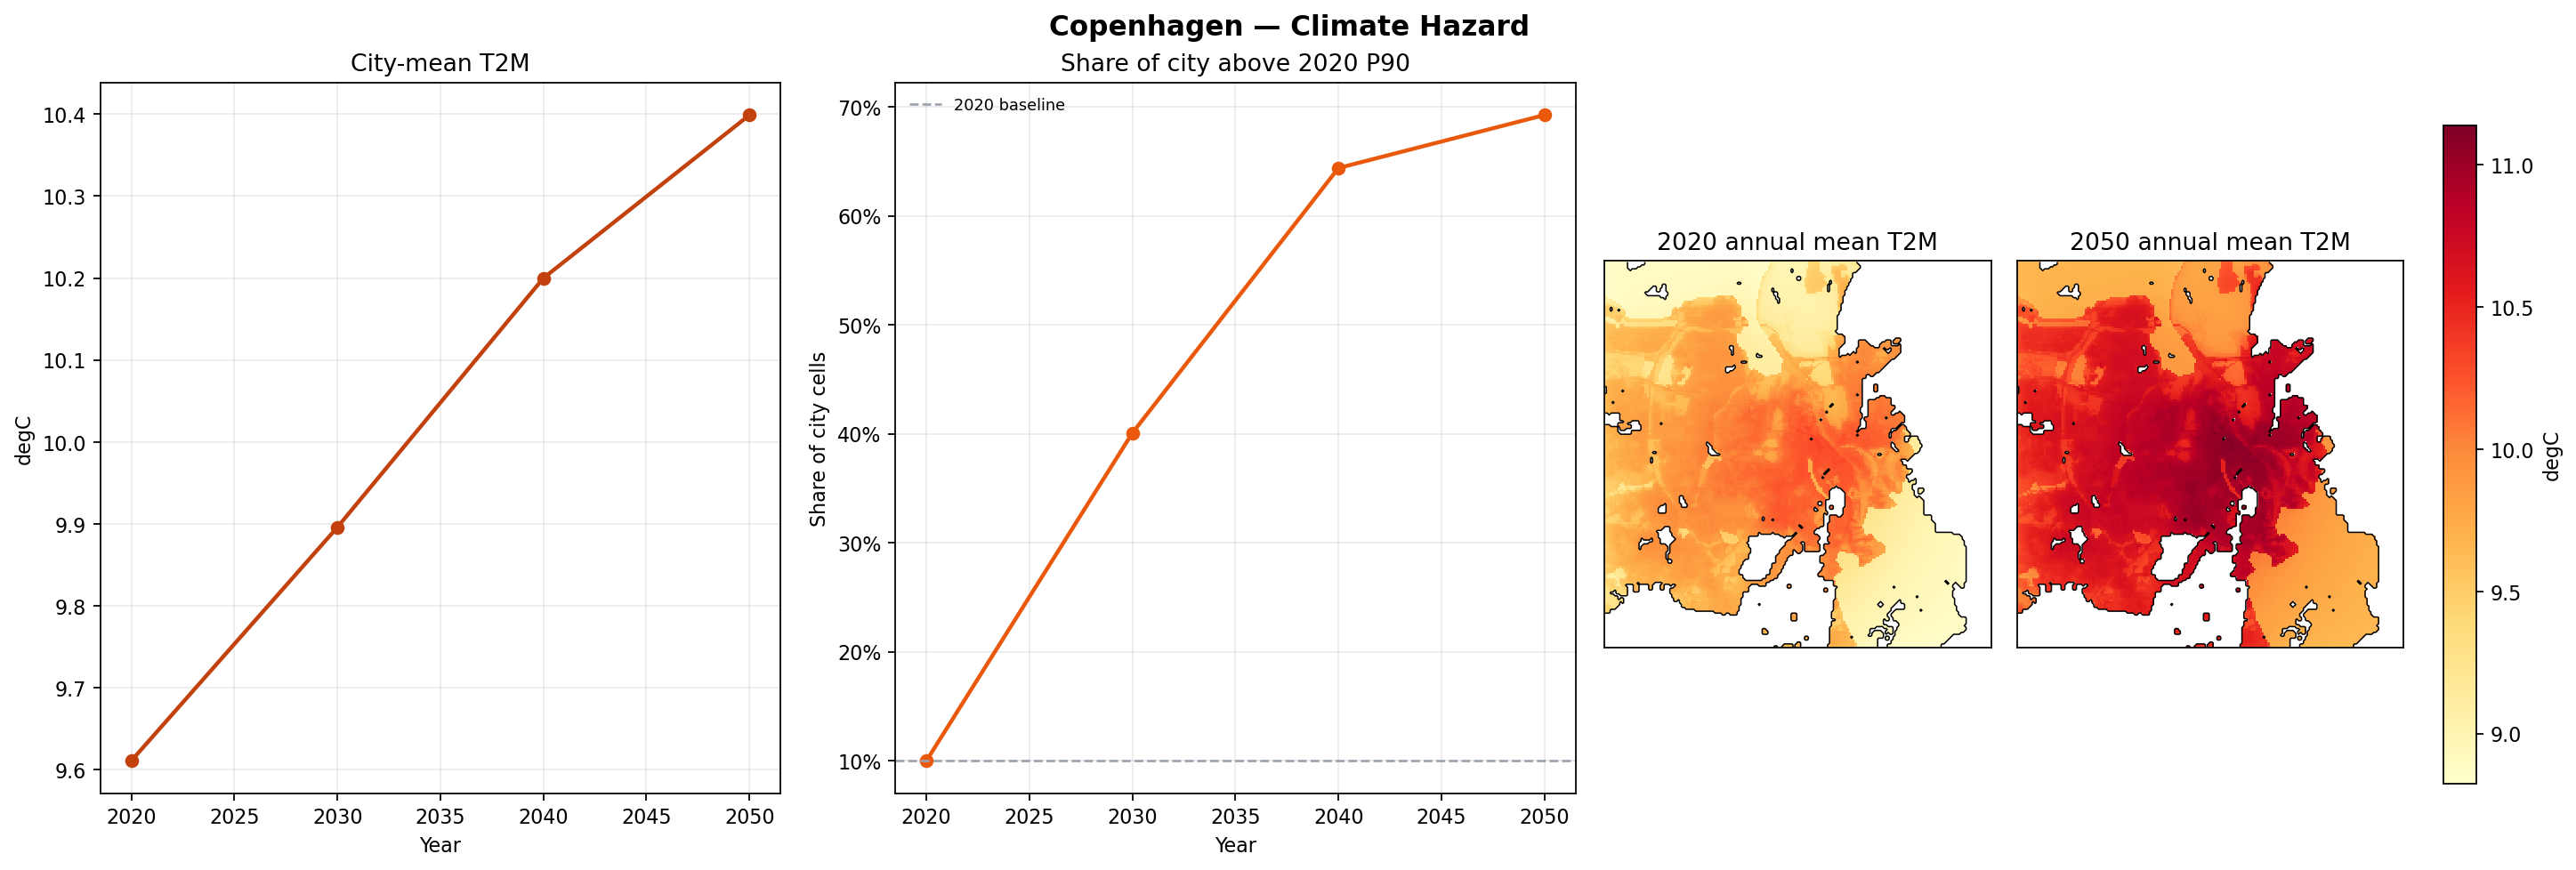

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_03_vulnerability_copenhagen.png


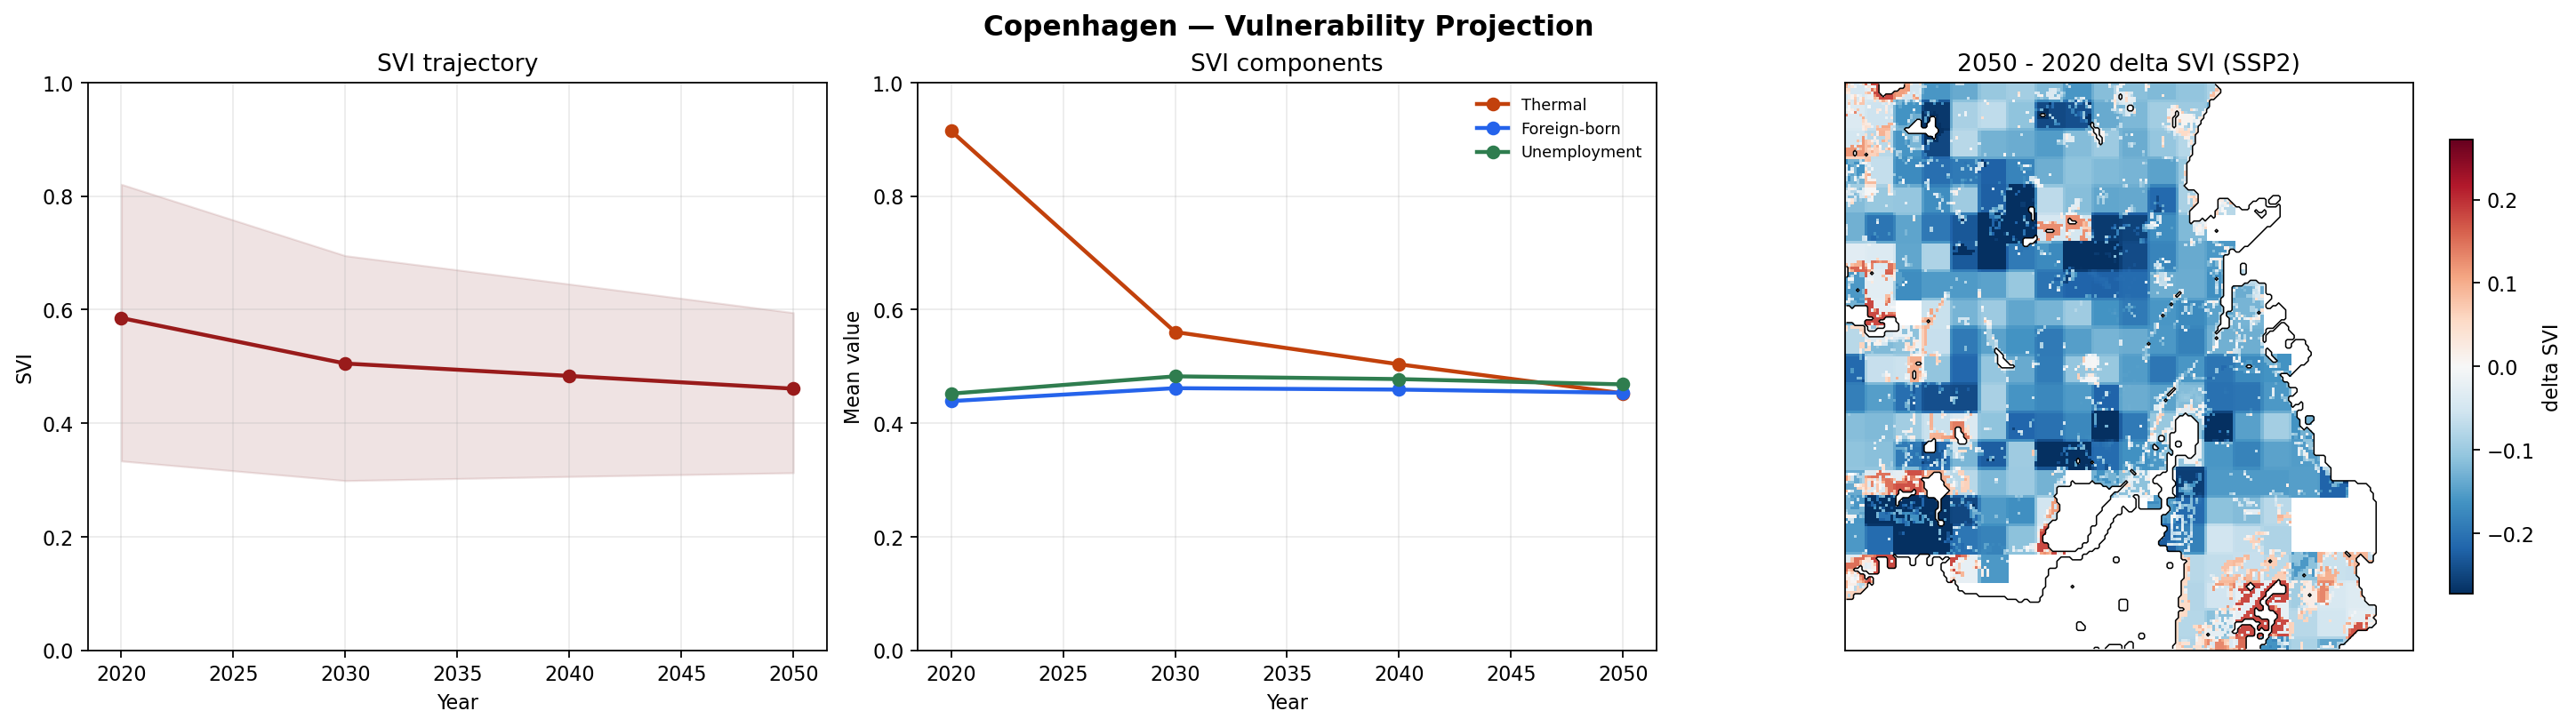

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_04_mortality_if_copenhagen.png


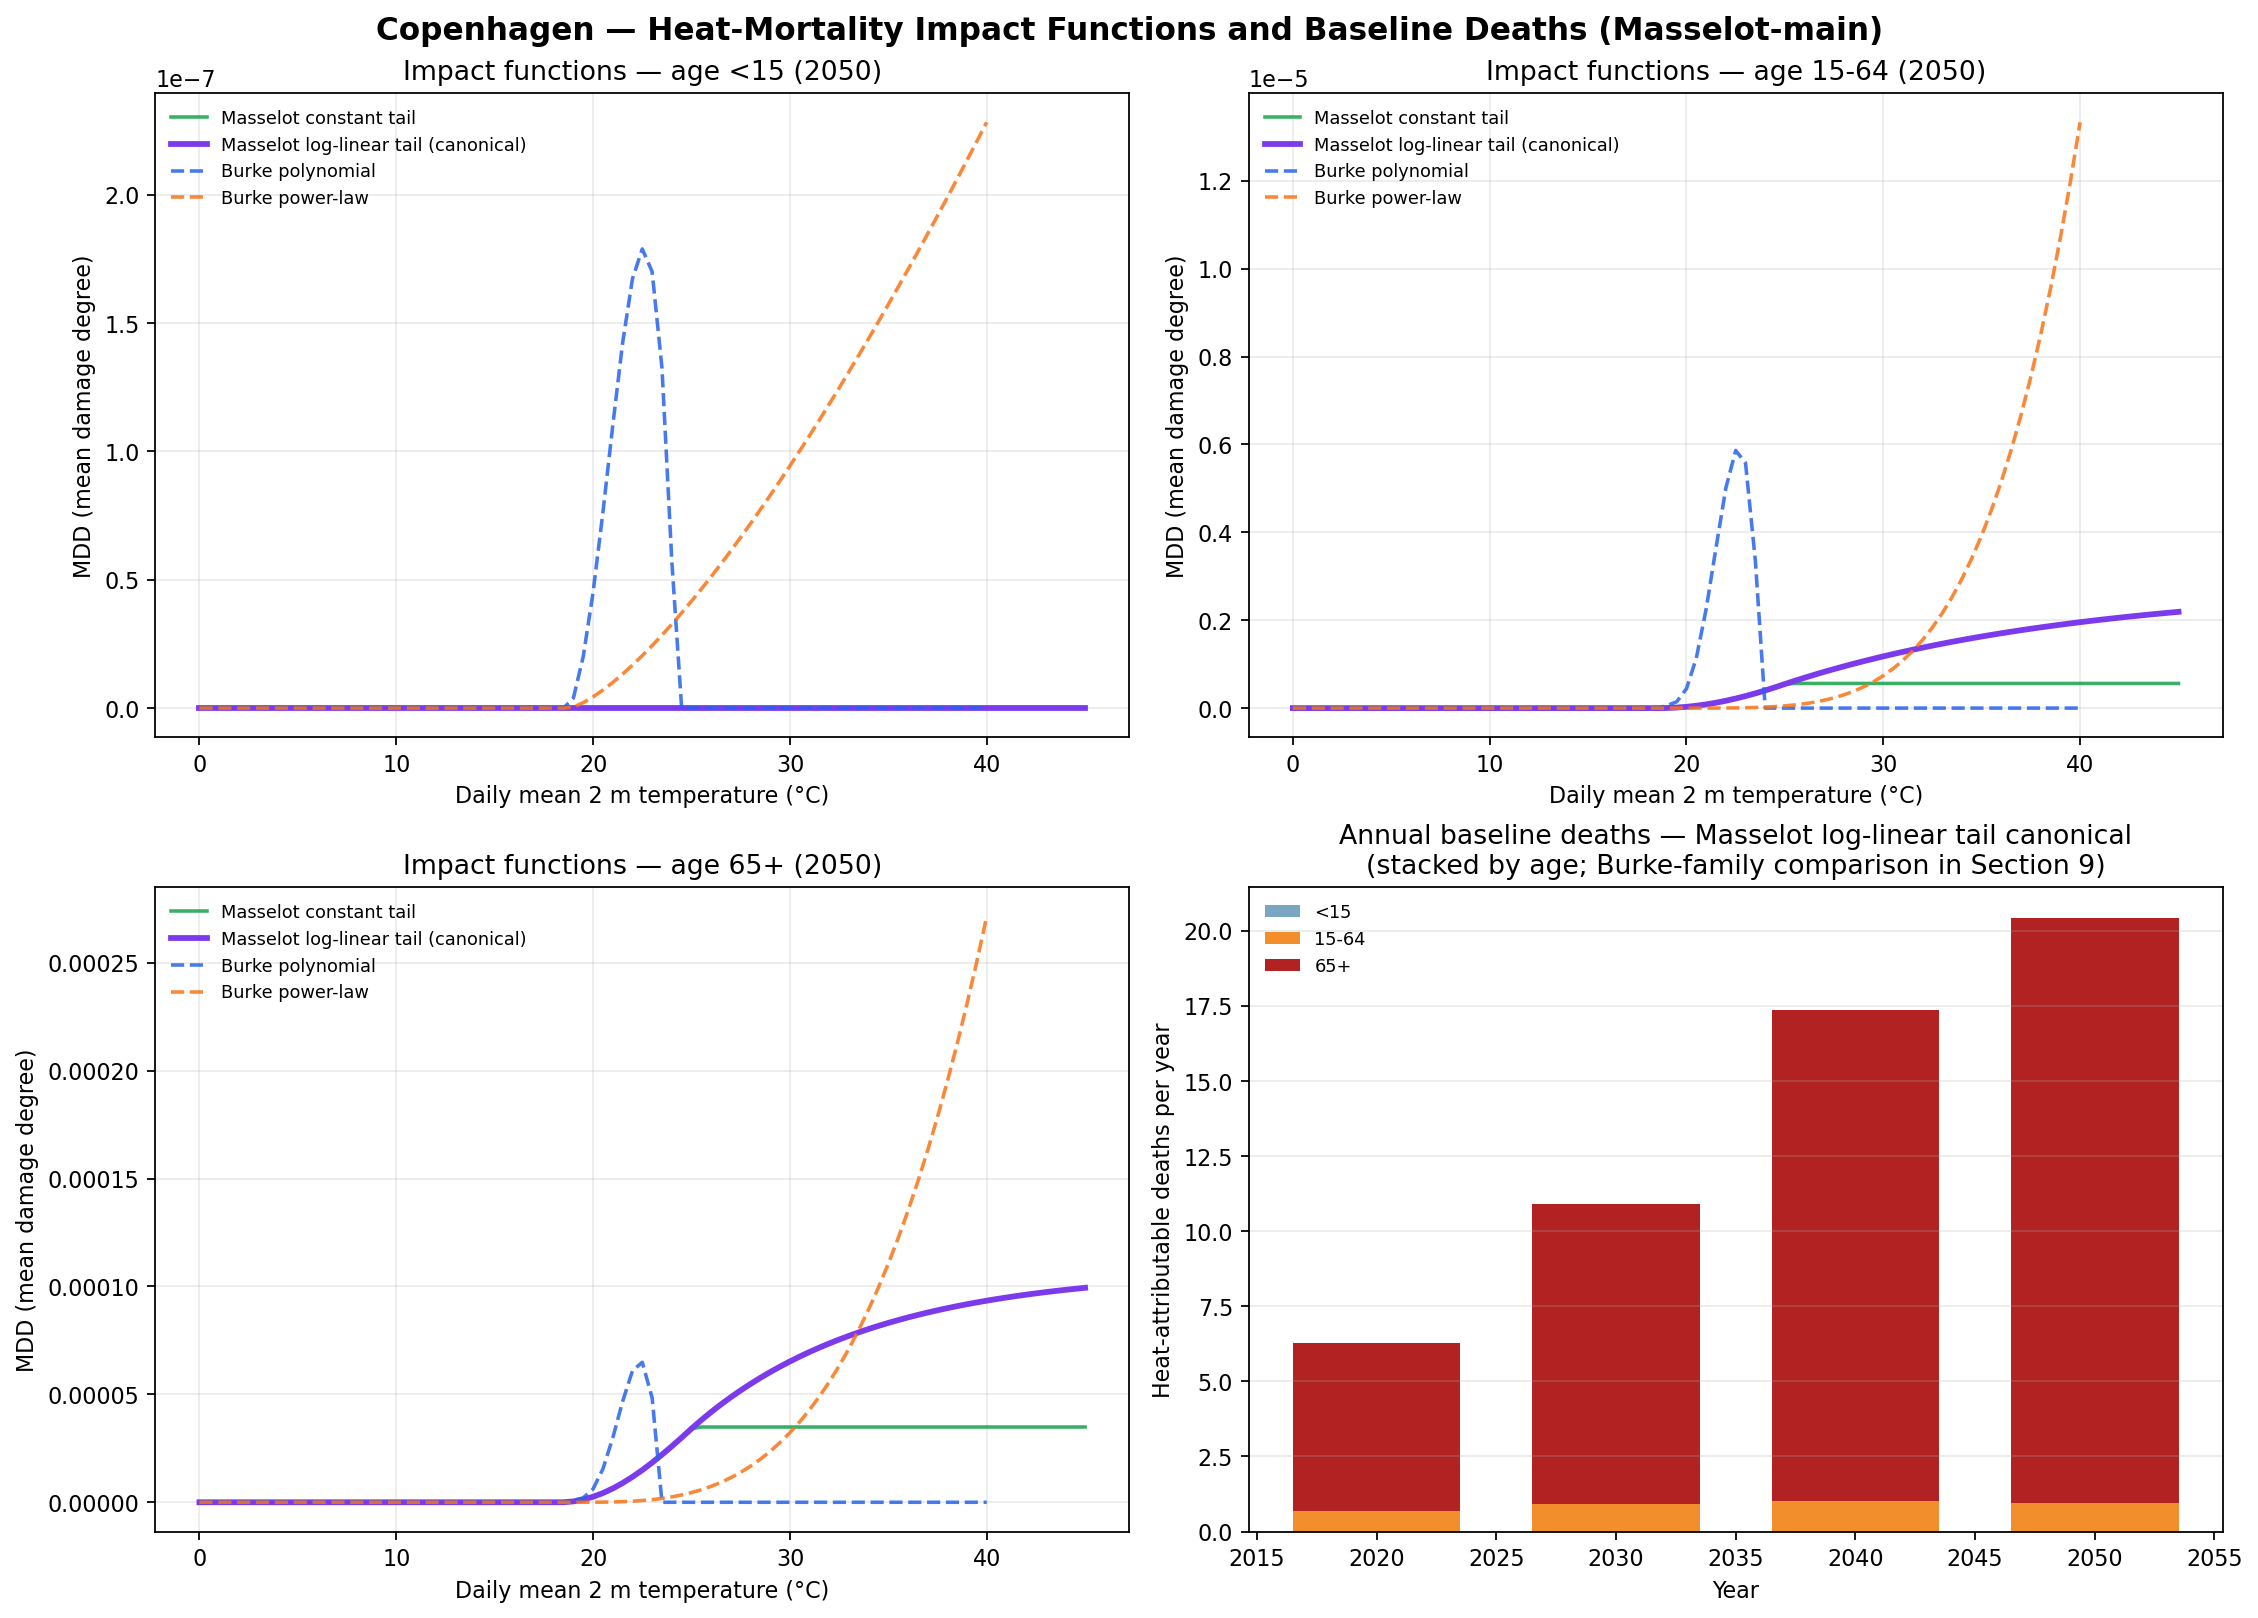

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_05_policy_levers_copenhagen.png


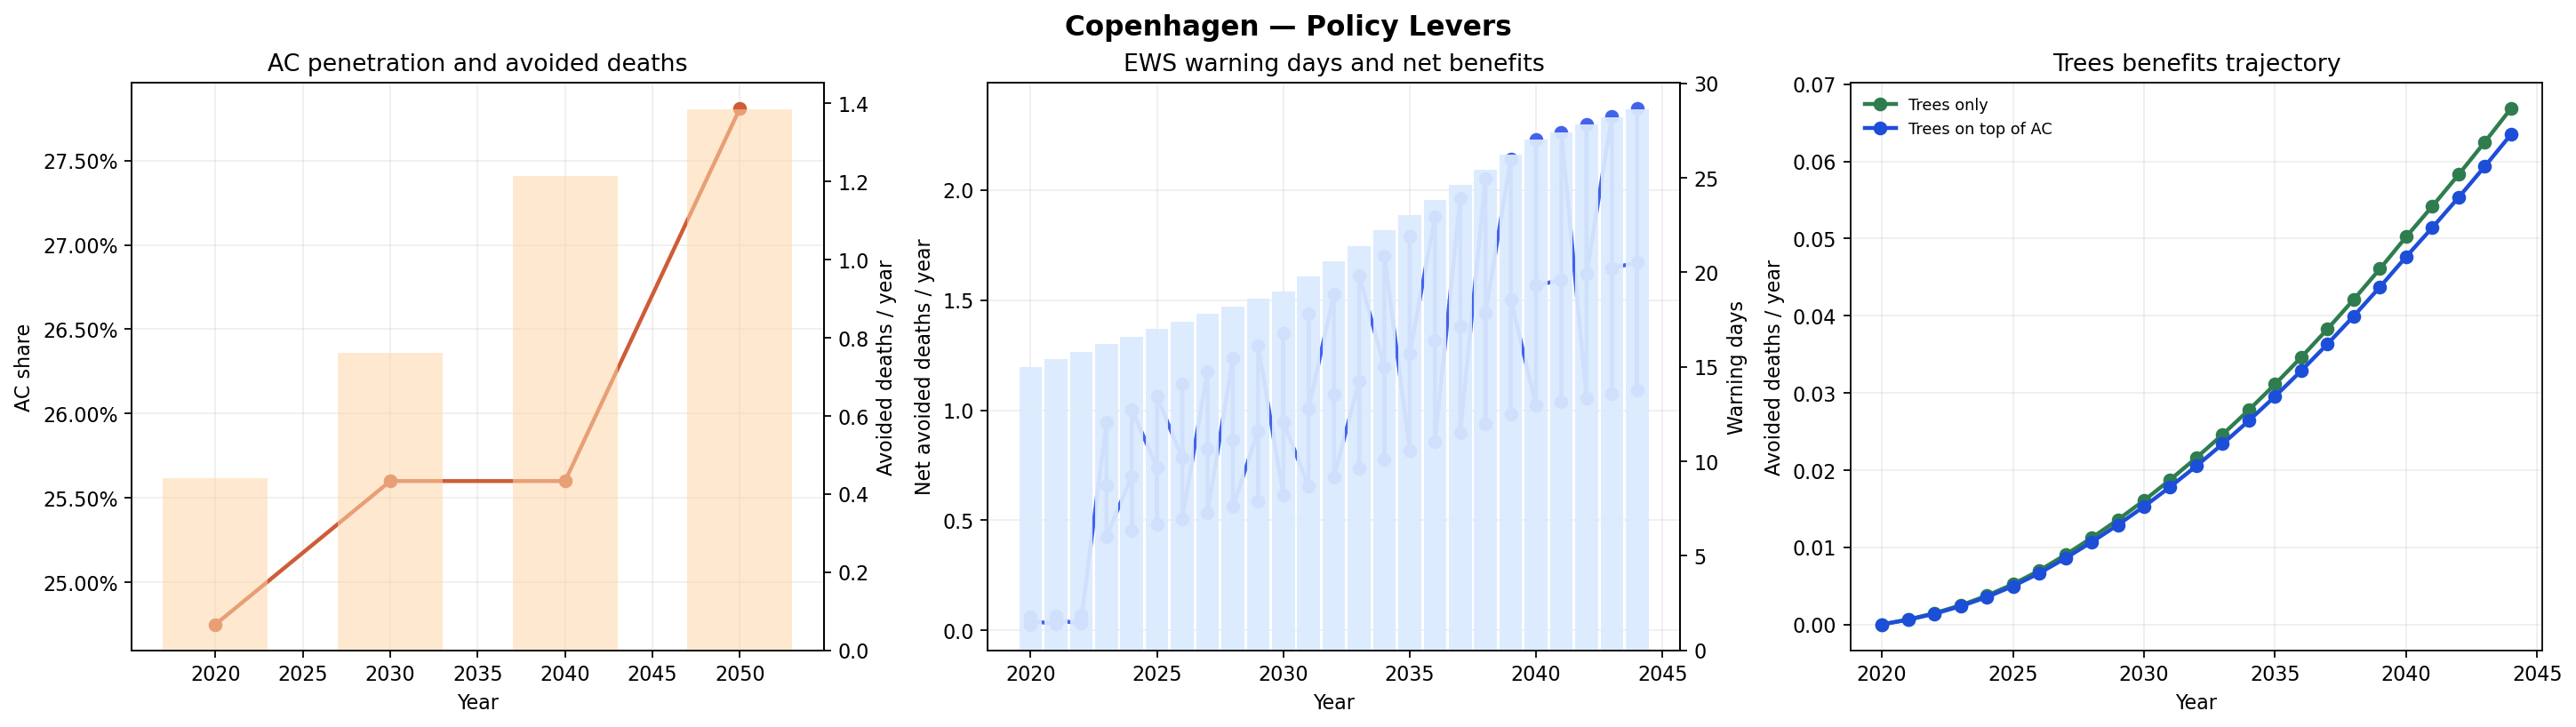

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_06_cba_dashboard_copenhagen.png


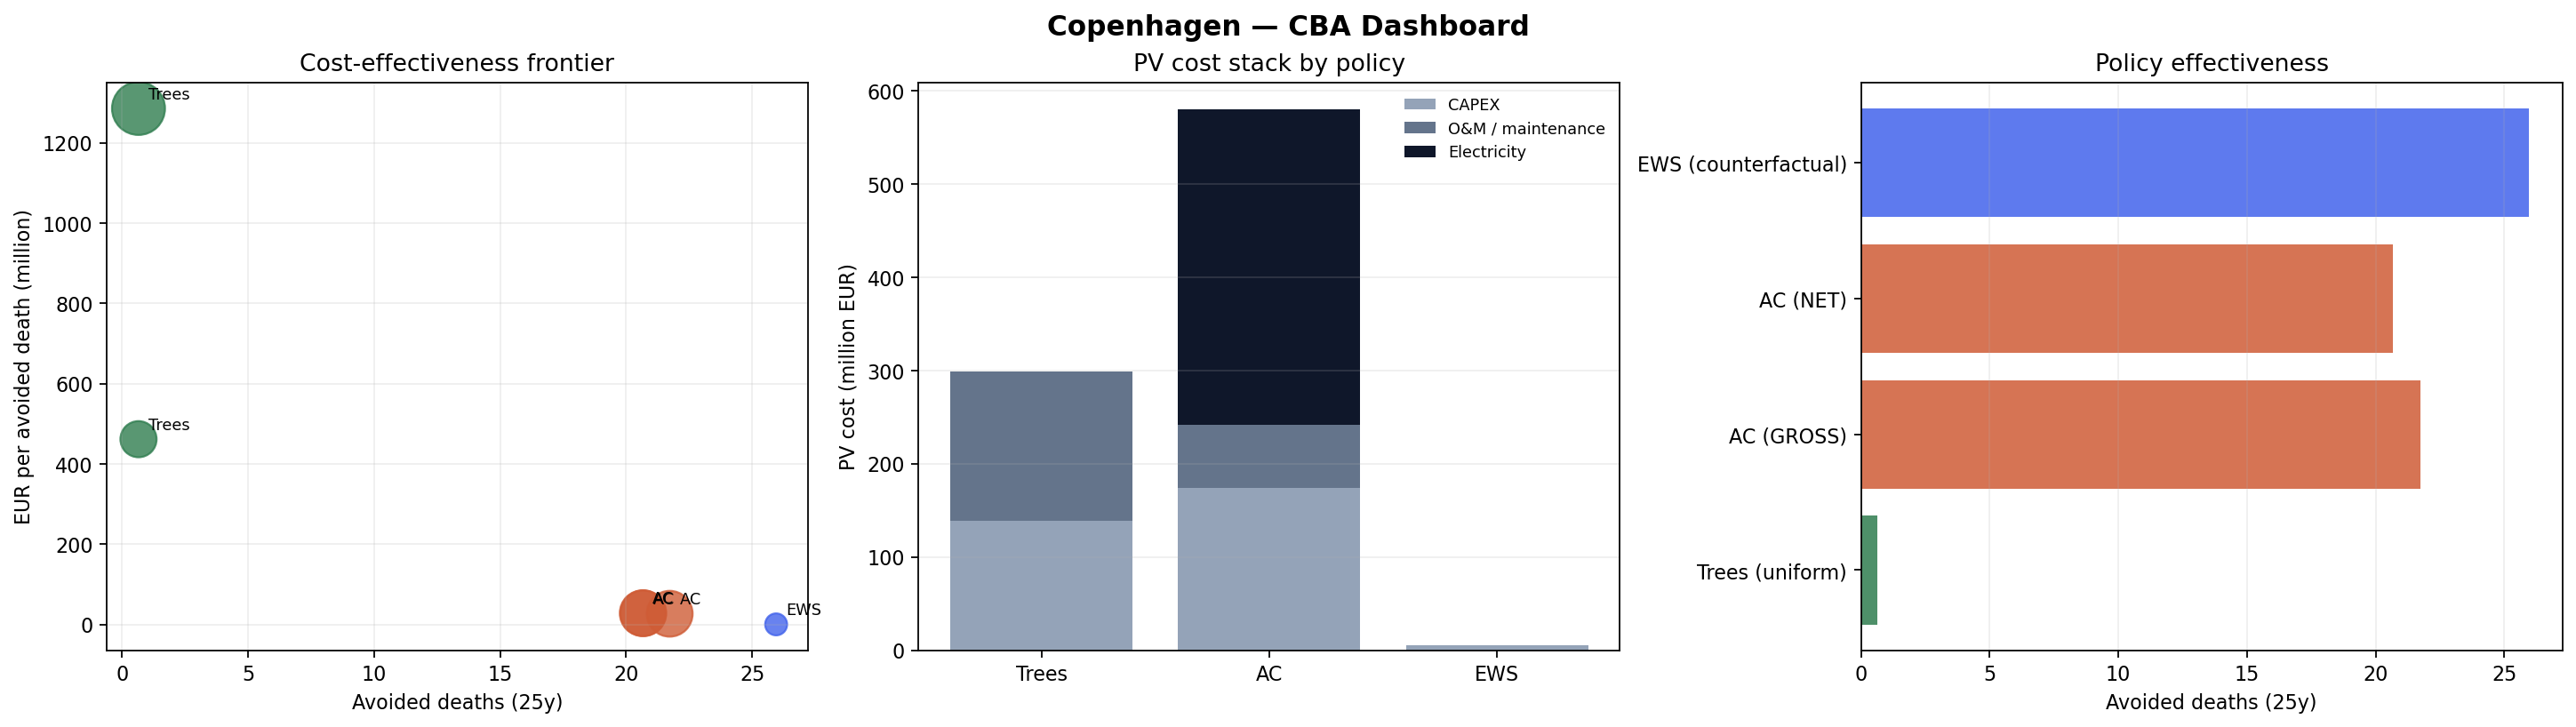

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_07_uncertainty_copenhagen.png


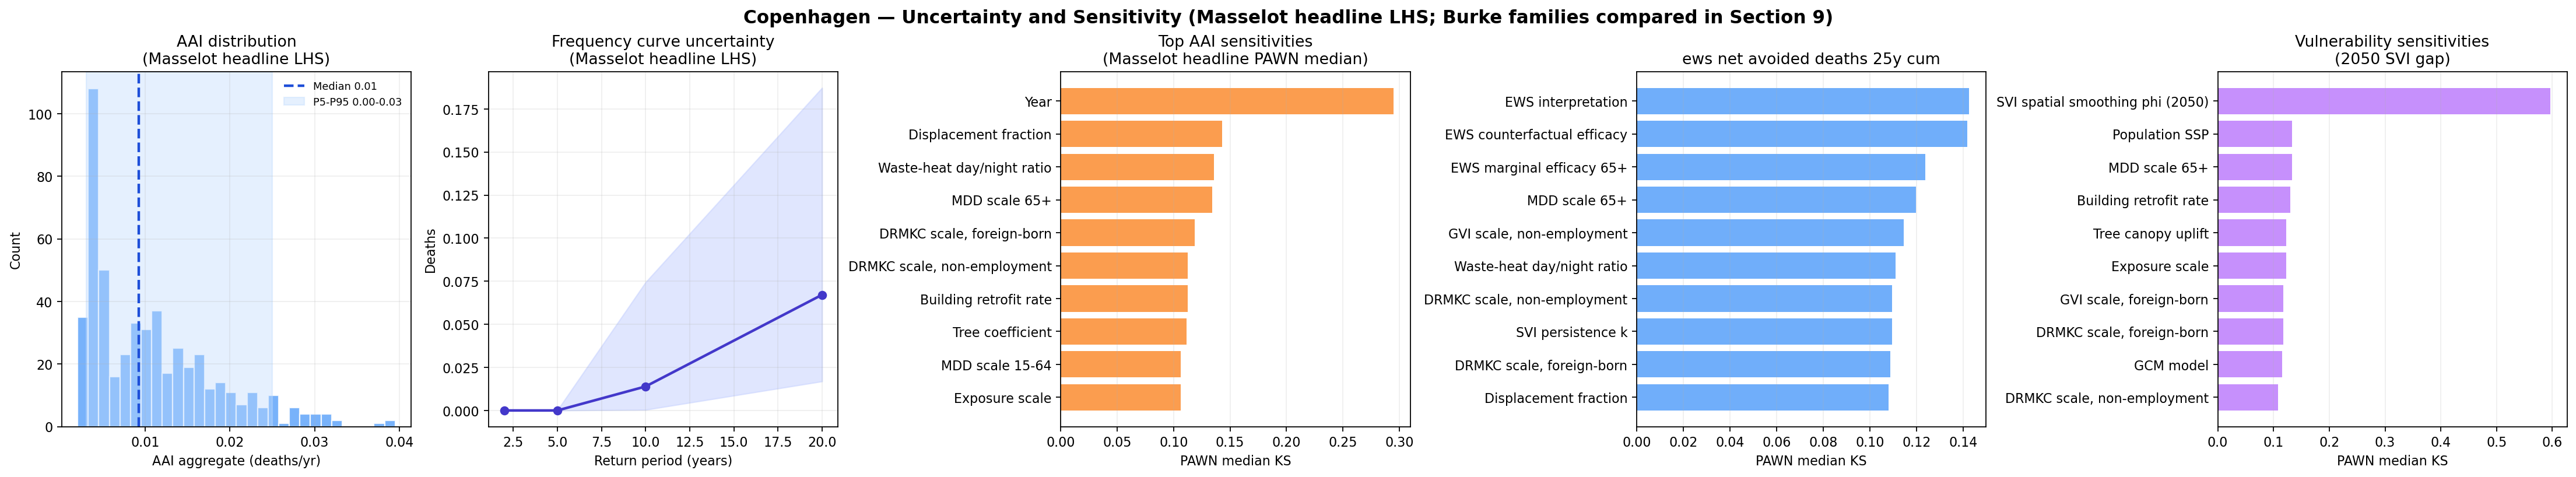

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_08_if_family_sensitivity_copenhagen.png


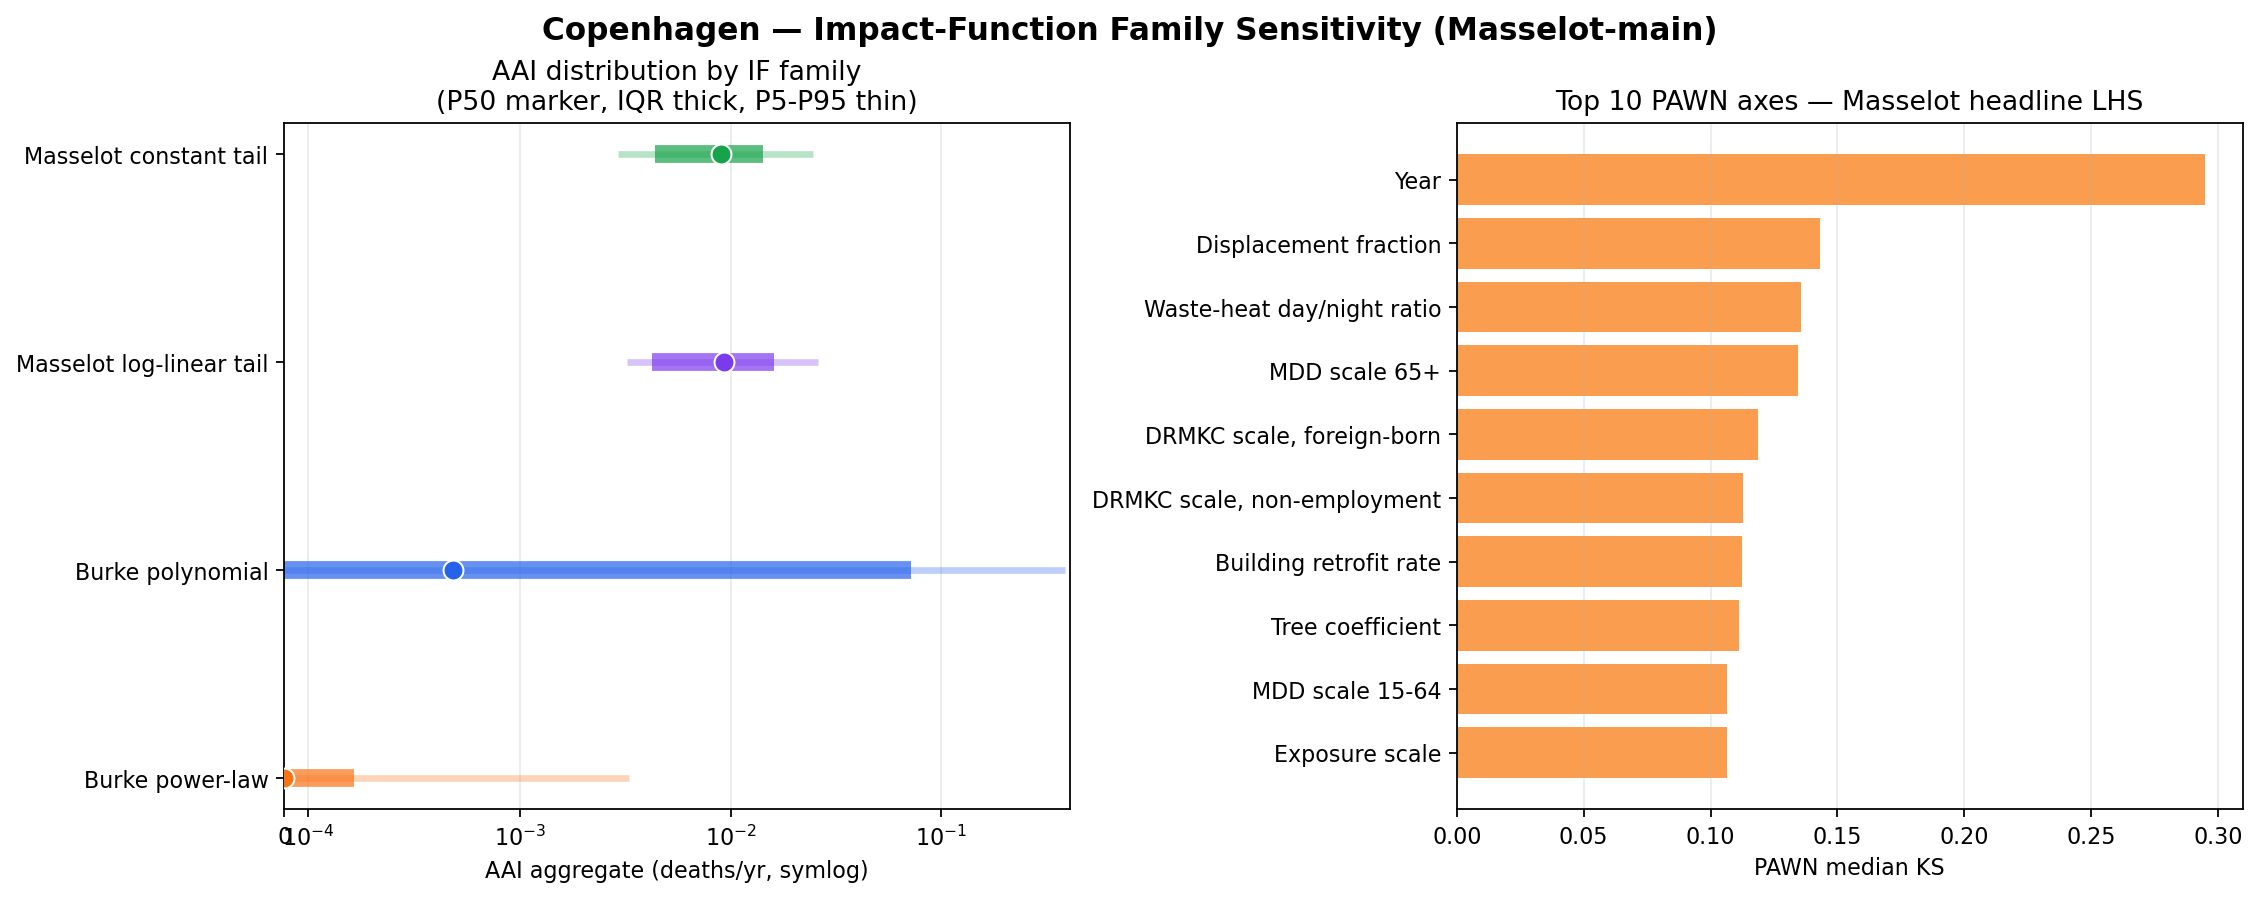

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/figures/summary/summary_09_if_source_comparison_copenhagen.png


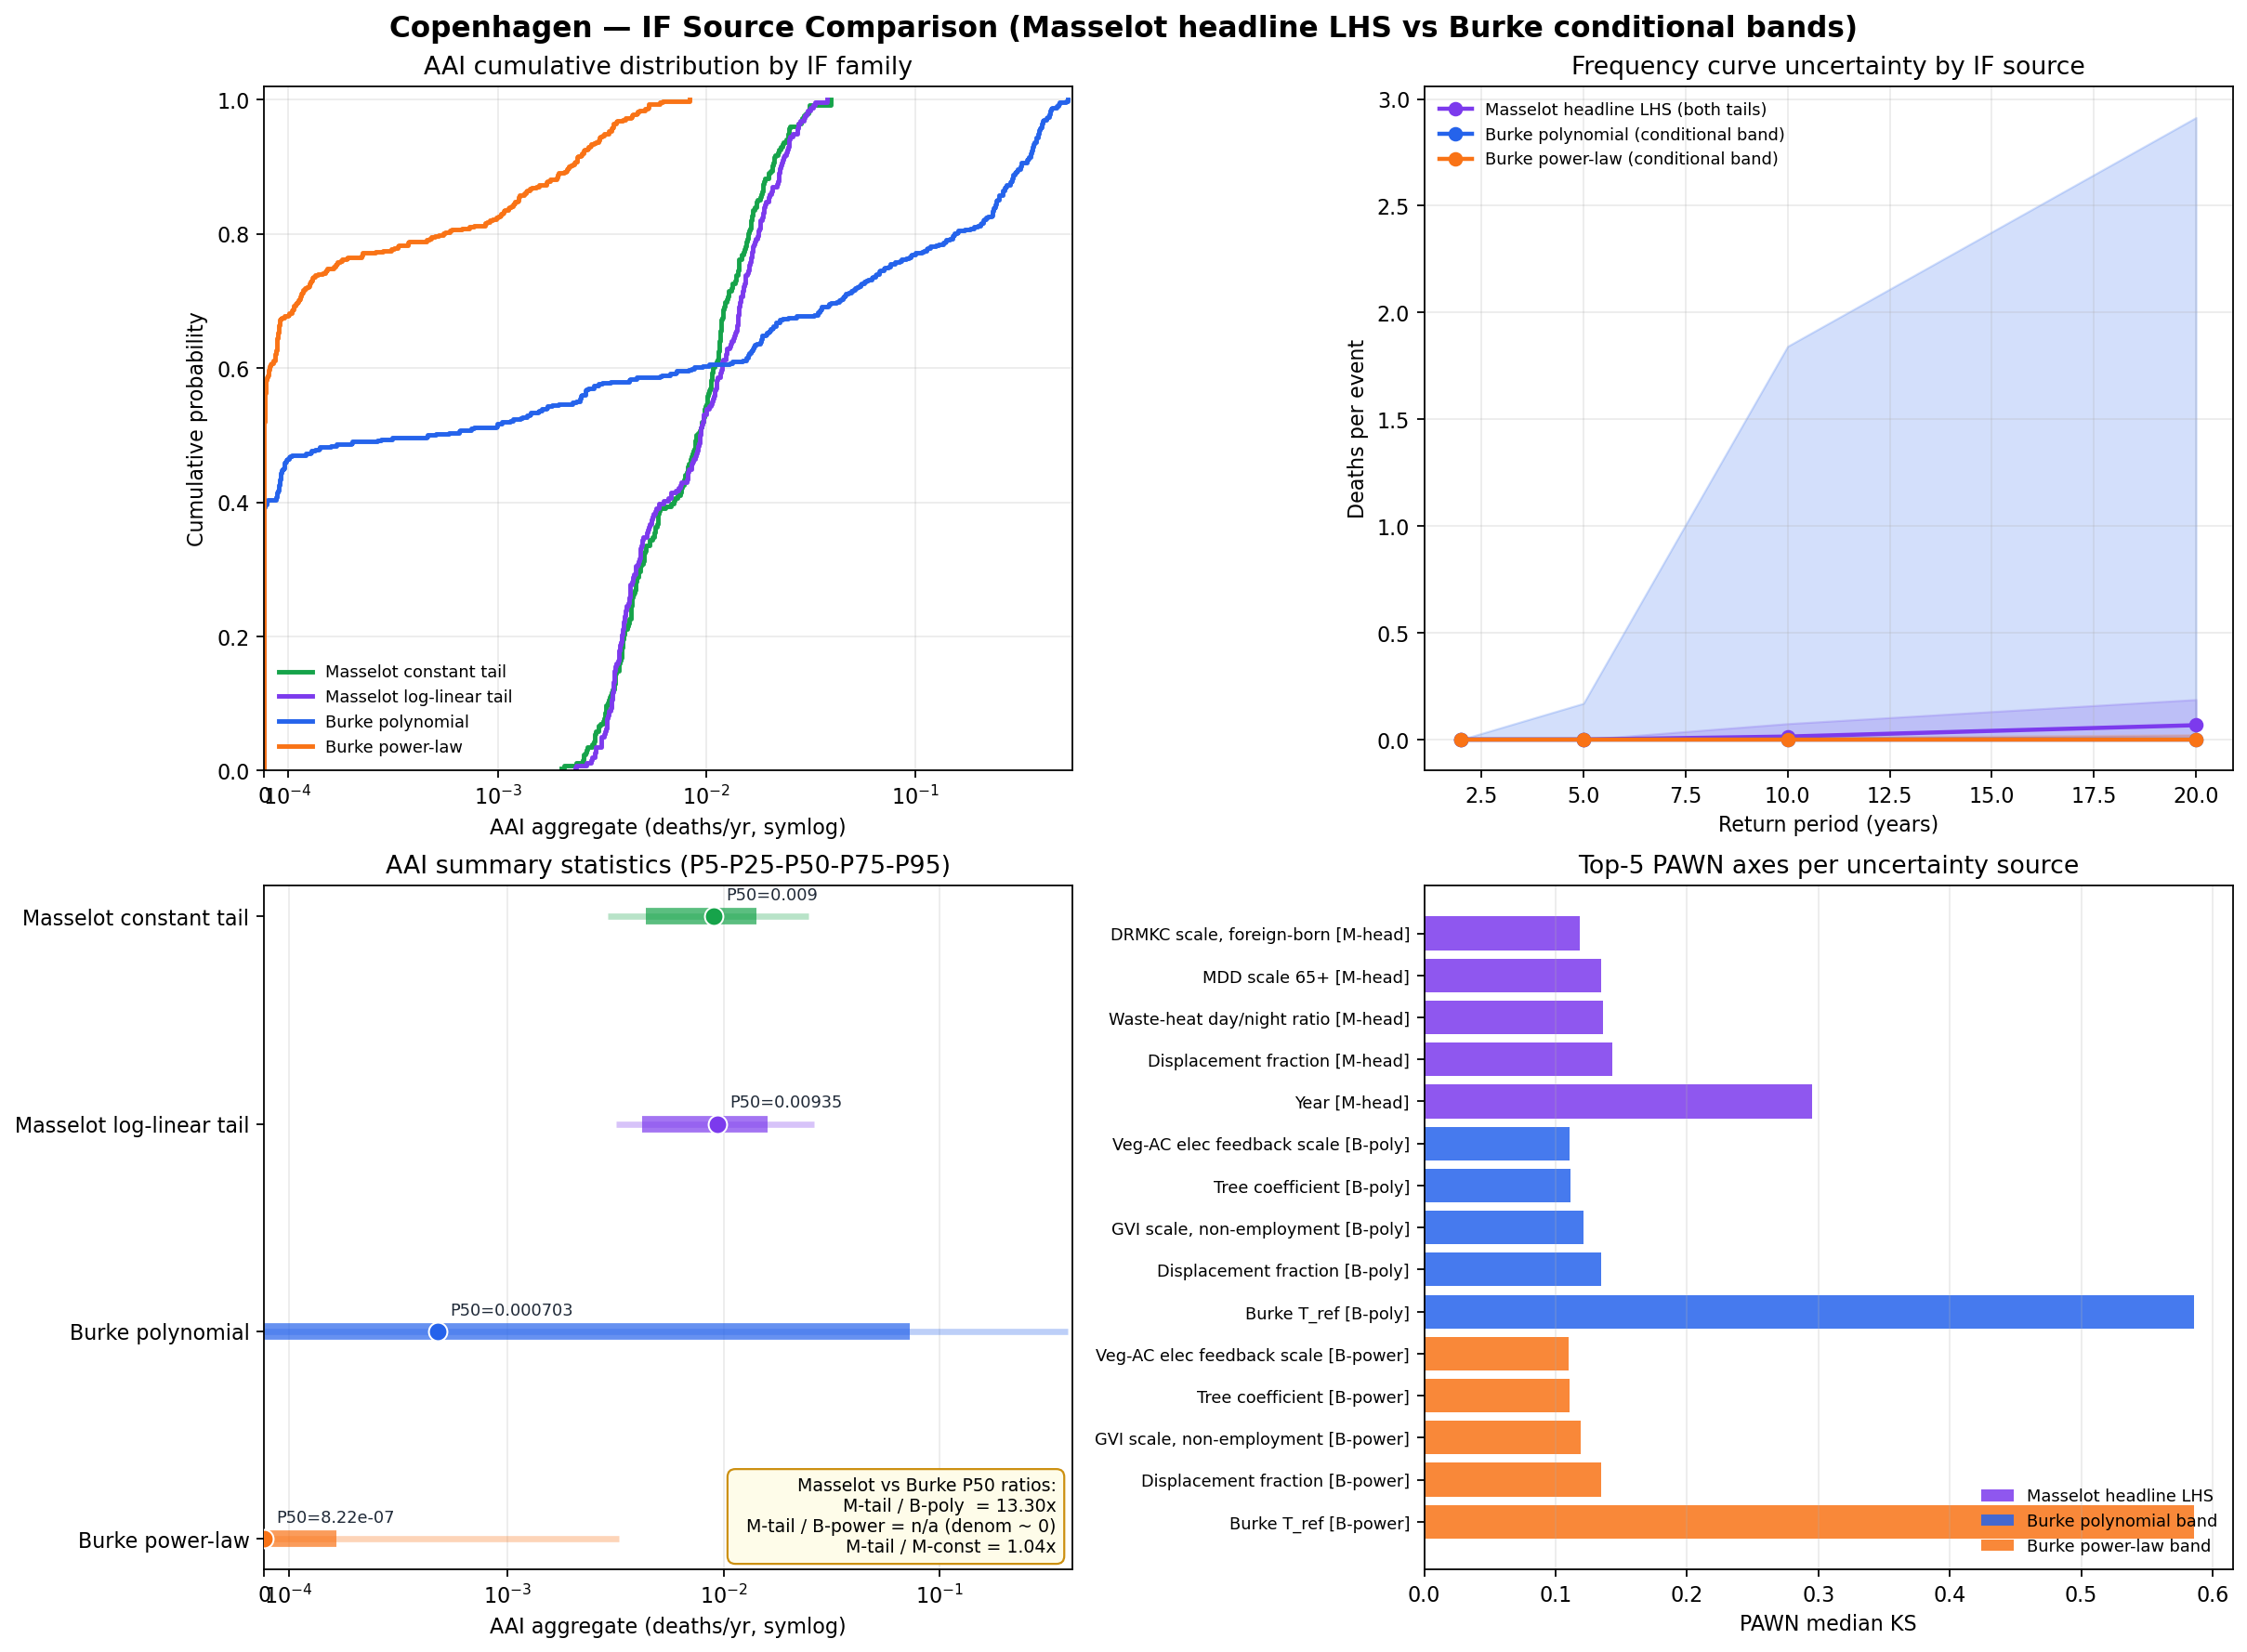

In [4]:
from IPython.display import Image, display

figure_paths = [
    path
    for key, paths in results.items()
    if key != "summary_metrics"
    for path in paths
]

for path in figure_paths:
    print(path)
    display(Image(filename=str(path)))

In [5]:
from cityheat.nbsetup_masselot_main import resolve_city_output
CITY_OUT = resolve_city_output(ROOT, CITY_SLUG)

import pandas as pd

metrics_path = CITY_OUT / "tables" / f"{CITY_SLUG}_framework_summary_metrics.csv"
metrics = pd.read_csv(metrics_path)
metrics

,section,metric,value,unit
0,run_config,output_variant,masselot_main,NaN
1,run_config,if_main_family,masselot_tail,NaN
2,run_config,if_main_source,Masselot,NaN
3,run_config,masselot_extrapolation,loglinear_tail,NaN
4,run_config,burke_role,sensitivity,NaN
5,run_config,current_original_workflow_preserved,True,NaN
6,run_config,masselot_tail_extrapolation,loglinear_tail,NaN
7,run_config,burke_recompute_audit_status,skipped_cross_track,NaN
8,run_config,burke_recompute_audit_fail_count,0,rows
9,run_config,burke_recompute_audit_strict,False,NaN


In [6]:
from cityheat.nbsetup_masselot_main import resolve_city_output
CITY_OUT = resolve_city_output(ROOT, CITY_SLUG)

# Explicit standard-vs-extreme side-by-side synthesis for Copenhagen.
import numpy as np
import pandas as pd

int_dir = CITY_OUT / "interim"
std_y = int_dir / f"hazard_events_T2M_yearly_{CITY_SLUG}.csv"
ext_y = int_dir / f"hazard_events_T2M_yearly_{CITY_SLUG}_extreme.csv"

if not std_y.exists() or not ext_y.exists():
    # Masselot-main variant: Track-B is intentionally disabled because the per-city MMT
    # supplies the heat signal that the cold-city Burke workaround used Track-B to fabricate.
    # Skip the side-by-side comparison gracefully rather than fail the summary notebook.
    missing = [str(_p) for _p in [std_y, ext_y] if not _p.exists()]
    print(f"Skipping standard-vs-extreme summary (Masselot-main runs Copenhagen on the standard track only). Missing: {missing}")
else:
    std = pd.read_csv(std_y).rename(columns={"citymean_degC": "trackA_citymean_degC"})
    ext = pd.read_csv(ext_y).rename(columns={
        "n_event_days": "trackB_event_days",
        "mean_event_intensity_citymean_degC": "trackB_mean_event_exceedance_degC",
        "max_event_intensity_citymean_degC": "trackB_max_event_exceedance_degC",
    })

    side = std.merge(ext[["year", "trackB_event_days", "trackB_mean_event_exceedance_degC", "trackB_max_event_exceedance_degC"]], on="year", how="left")
    side["trackB_event_days"] = side["trackB_event_days"].fillna(0).astype(int)
    for c in ["trackB_mean_event_exceedance_degC", "trackB_max_event_exceedance_degC"]:
        side[c] = side[c].fillna(0.0)

    side["trackA_has_policy_signal"] = np.where(side["trackA_citymean_degC"] > 0, "baseline-only (cold-city)", "baseline-only")

    out_csv = CITY_OUT / "tables" / f"{CITY_SLUG}_standard_vs_extreme_summary.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    side.to_csv(out_csv, index=False)
    print(f"Saved side-by-side track summary -> {out_csv}")
    side

Skipping standard-vs-extreme summary (Masselot-main runs Copenhagen on the standard track only). Missing: ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/interim/hazard_events_T2M_yearly_copenhagen_extreme.csv']
